## Notebook 03 - Exploratory Data Analysis (EDA)

### Objective

This notebook performs exploratory data analysis on the cleaned Olist datasets to uncover customer behavior, sales trends, and revenue insights.

### Business Questions

- What is the order status distribution?
- How do sales change over time?
- Which states generate the most revenue?
- Which payment methods are most common?
- Which customers contribute the highest revenue?
- What business insights can be derived?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [10]:
# Project Root Directory
BASE_DIR = Path.cwd().parent 
# Original Data Folder 
DATA_DIR = BASE_DIR / "Data"
print("Project Directory :", BASE_DIR)
print("Data Directory :", DATA_DIR)

Project Directory : d:\360 Analytics project
Data Directory : d:\360 Analytics project\Data


In [11]:
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv") 
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv") 
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv") 
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")

In [12]:
print("Customers :", customers.shape) 
print("Orders :", orders.shape)
print("Order Items :", order_items.shape)
print("Payments :", payments.shape)
print("Reviews :", reviews.shape)

Customers : (99441, 5)
Orders : (99441, 8)
Order Items : (112650, 7)
Payments : (103886, 5)
Reviews : (99224, 7)


In [13]:
datasets = { "Customers": customers, "Orders": orders, "Order Items": order_items, "Payments": payments, "Reviews": reviews }

In [14]:
overview = pd.DataFrame({
    "Dataset": [
        "Customers",
        "Orders",
        "Order Items",
        "Payments",
        "Reviews"
    ],
    "Rows": [
        customers.shape[0],
        orders.shape[0],
        order_items.shape[0],
        payments.shape[0],
        reviews.shape[0]
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        order_items.shape[1],
        payments.shape[1],
        reviews.shape[1]
    ]
})

overview

,Dataset,Rows,Columns
0,Customers,99441,5
1,Orders,99441,8
2,Order Items,112650,7
3,Payments,103886,5
4,Reviews,99224,7


In [15]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(df.isnull().sum())
    print()

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_

In [16]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Customers: 0 duplicate rows
Orders: 0 duplicate rows
Order Items: 0 duplicate rows
Payments: 0 duplicate rows
Reviews: 0 duplicate rows


In [17]:
for name, df in datasets.items():
    memory = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name}: {memory:.2f} MB")

Customers: 26.59 MB
Orders: 52.94 MB
Order Items: 35.99 MB
Payments: 16.23 MB
Reviews: 39.12 MB


Merge Datasets


Step 1 — Customers + Orders

In [18]:
customer_orders = customers.merge(
    orders,
    on="customer_id",
    how="inner"
)

print(customer_orders.shape)

(99441, 12)


In [19]:
customer_orders_payments = customer_orders.merge(
    payments,
    on="order_id",
    how="inner"
)

print(customer_orders_payments.shape)

(103886, 16)


In [20]:
customer_orders_payments_items = customer_orders_payments.merge(
    order_items,
    on="order_id",
    how="inner"
)

print(customer_orders_payments_items.shape)

(117601, 22)


In [21]:
customer_orders_payments_items.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,credit_card,2,146.87,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,credit_card,8,335.48,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,credit_card,7,157.73,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,credit_card,1,173.30,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,credit_card,8,252.25,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25


Univariate Analysis


Order Status
Payment Type
Review Score
Customer State
Order Value Distribution

In [ ]:
# Order Status Distribution
status_counts = orders["order_status"].value_counts()

status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

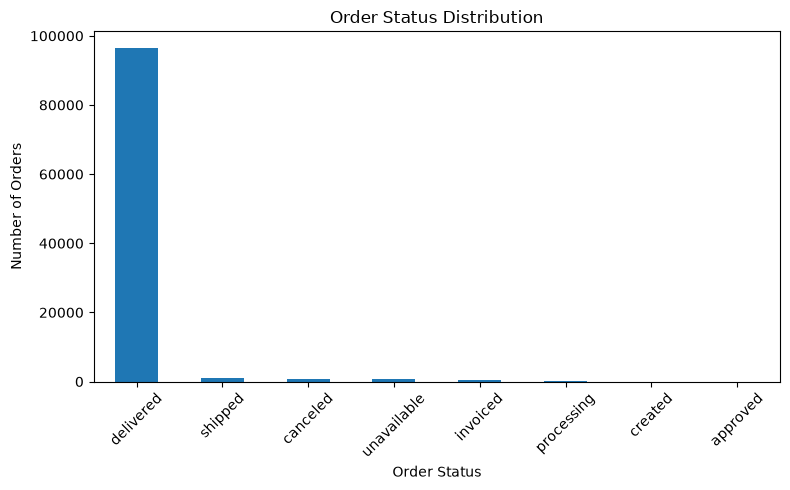

In [53]:
plt.figure(figsize=(8,5))

fig, ax = plt.subplots(figsize=(8,5))

status_counts = orders["order_status"].value_counts()

status_counts.plot(kind="bar", ax=ax)

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

The majority of customer orders were successfully delivered.

Only a very small percentage of orders were canceled or unavailable.

## Business Insight

A high delivery success rate indicates strong logistics and operational efficiency.

## Recommendation

Continue monitoring cancellation reasons to further improve customer satisfaction.

In [24]:
# Payment Type Distribution
payment_counts = payments["payment_type"].value_counts()

payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

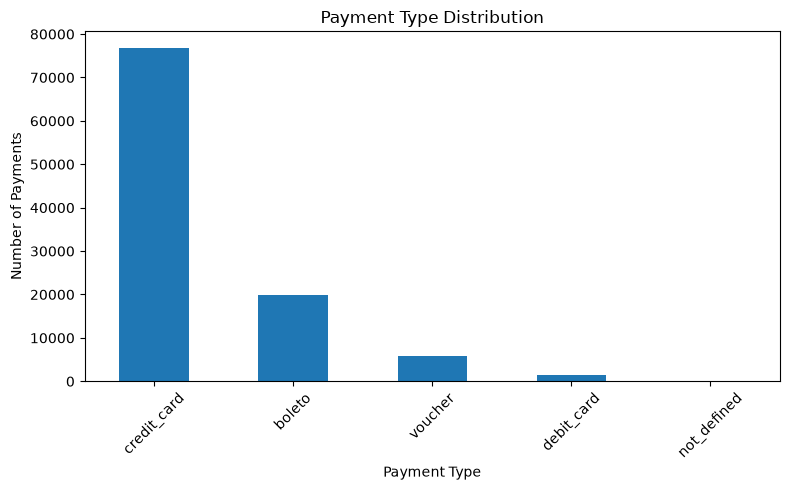

In [52]:
plt.figure(figsize=(8,5))

payment_counts = payments["payment_type"].value_counts()

payment_counts.plot(kind="bar")

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "Images/Payment_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Credit card is the dominant payment method.

## Business Insight

Customers prefer flexible payment options, making credit card transactions the primary revenue channel.

## Recommendation

Maintain reliable credit card processing while encouraging alternative payment methods where appropriate.

In [47]:
# Review Score Distribution

review_counts = reviews["review_score"].value_counts().sort_index()

review_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

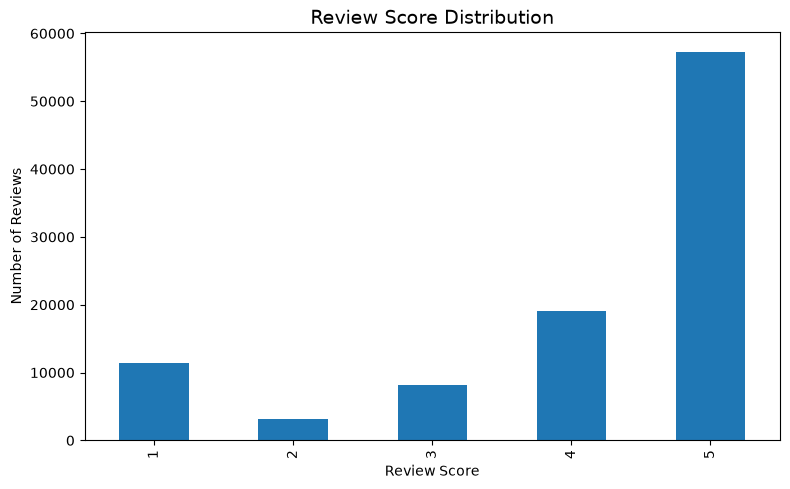

In [51]:

fig, ax = plt.subplots(figsize=(8,5))

review_counts.plot(kind="bar", ax=ax)

ax.set_title("Review Score Distribution", fontsize=14)
ax.set_xlabel("Review Score")
ax.set_ylabel("Number of Reviews")

plt.tight_layout()

fig.savefig(
    "Images/review_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Most customers gave high ratings, particularly 4 and 5 stars.

## Business Insight

Overall customer satisfaction appears strong.

## Recommendation

Investigate low-rated reviews to identify recurring issues and improve customer experience.

In [28]:
# Top Customer States

state_counts = customers["customer_state"].value_counts()

state_counts.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

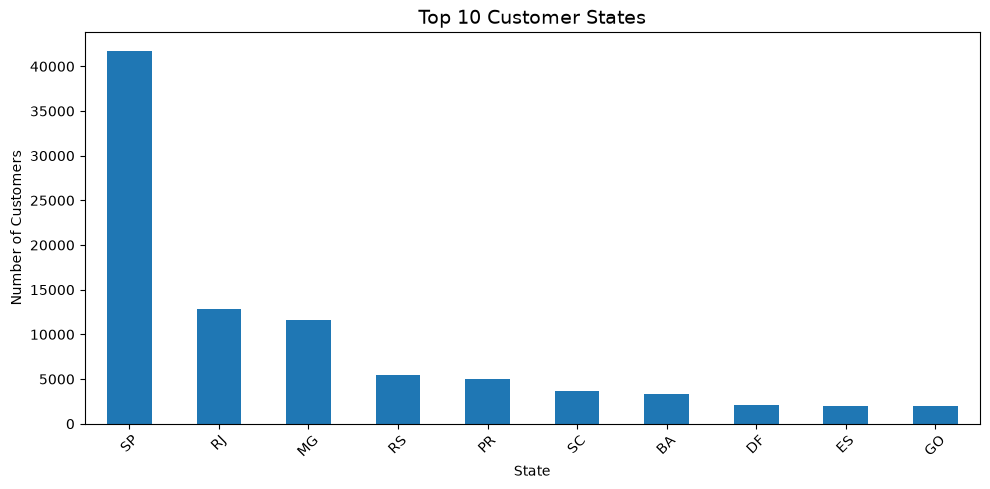

In [50]:
state_counts = customers["customer_state"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10,5))

state_counts.plot(kind="bar", ax=ax)

ax.set_title("Top 10 Customer States", fontsize=14)
ax.set_xlabel("State")
ax.set_ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/top10_customer_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

A small number of states contribute a large share of the customer base.

## Business Insight

Customer demand is concentrated geographically.

## Recommendation

Focus marketing campaigns and inventory planning in high-demand regions while exploring opportunities to grow in lower-penetration states.

In [30]:
# Payment Value Distribution

payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

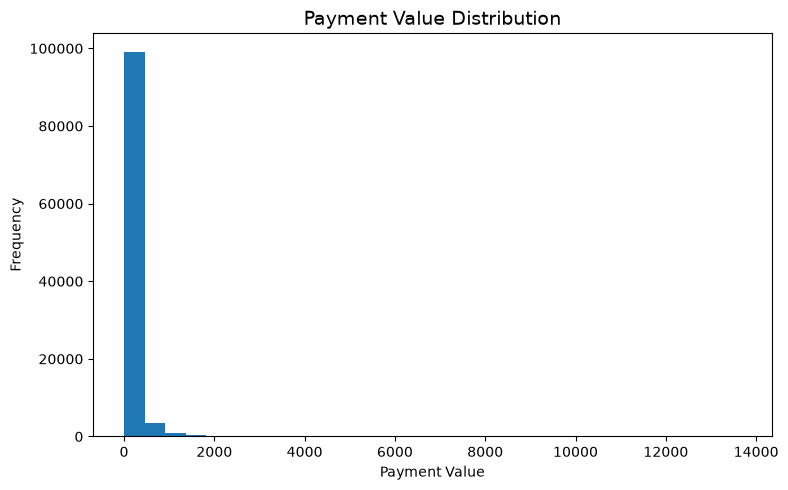

In [54]:
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(
    payments["payment_value"],
    bins=30
)

ax.set_title("Payment Value Distribution", fontsize=14)
ax.set_xlabel("Payment Value")
ax.set_ylabel("Frequency")

plt.tight_layout()

fig.savefig(
    "Images/payment_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

Most payment values are relatively small, with a small number of high-value transactions.

## Business Insight

The revenue distribution is right-skewed, indicating many low-value purchases and a few premium transactions.

## Recommendation

Increase average order value through product bundles, personalized recommendations, or promotional offers.

Bivariate Analysis
Objective

Analyze relationships between two business variables, such as:

Payment Type vs Revenue
Order Status vs Revenue
Payment Type vs Average Payment
Payment Installments vs Payment Value
Review Score vs Average Payment

Revenue by Payment Type
Business Question

Which payment method generates the highest revenue?

In [55]:
payment_revenue = (
    payments.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

display(payment_revenue)



payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

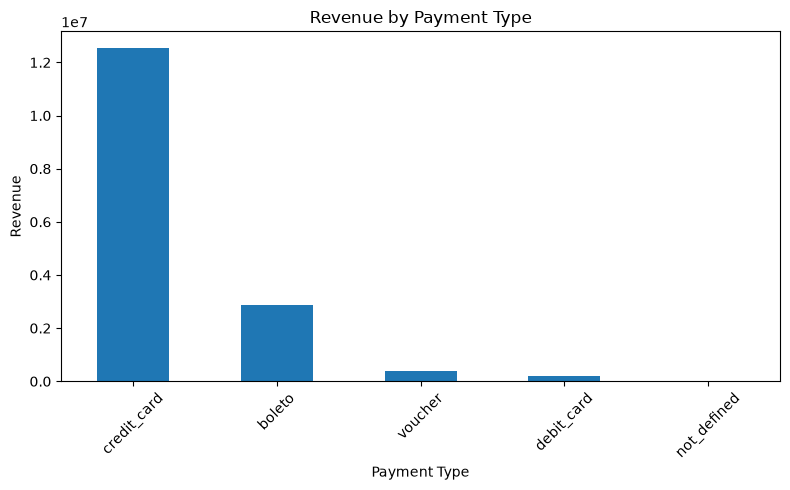

In [58]:
fig, ax = plt.subplots(figsize=(8,5))

payment_revenue.plot(kind="bar", ax=ax)

ax.set_title("Revenue by Payment Type")
ax.set_xlabel("Payment Type")
ax.set_ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    "Images/01_revenue_by_payment_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



Business Insight
Credit cards contribute the largest share of revenue.


Alternative payment methods contribute much less.


Prioritize a seamless credit card payment experience while encouraging other digital payment options.

Average Payment Value by Payment Type
Business Question

Which payment method has the highest average transaction value?

In [59]:
avg_payment = (
    payments.groupby("payment_type")["payment_value"]
    .mean()
    .sort_values(ascending=False)
)

display(avg_payment)

payment_type
credit_card    163.319021
boleto         145.034435
debit_card     142.570170
voucher         65.703354
not_defined      0.000000
Name: payment_value, dtype: float64

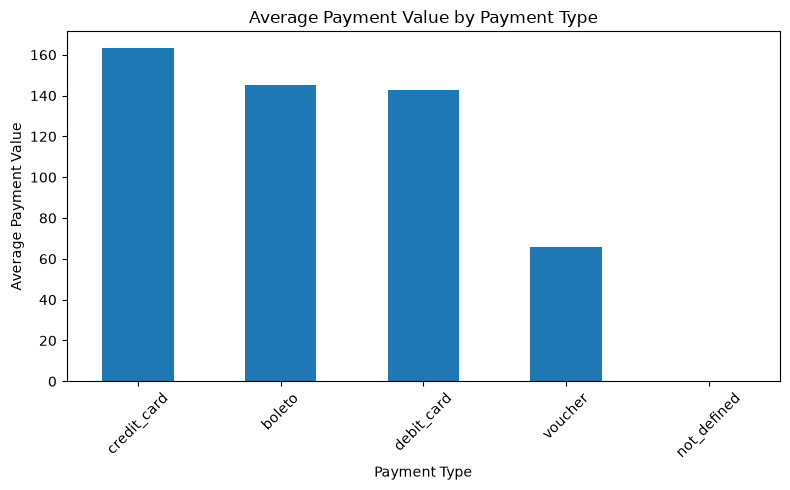

In [61]:
fig, ax = plt.subplots(figsize=(8,5))

avg_payment.plot(kind="bar", ax=ax)

ax.set_title("Average Payment Value by Payment Type")
ax.set_xlabel("Payment Type")
ax.set_ylabel("Average Payment Value")

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    "Images/02_avg_payment_by_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
Some payment methods are associated with higher-value purchases.
Marketing teams can promote these methods for premium products.

Order Status vs Revenue
Business Question

How much revenue comes from each order status?

In [62]:
# Merge Orders and Payments
orders_payments = orders.merge(
    payments,
    on="order_id",
    how="inner"
)

In [66]:

# Revenue Calculation
status_revenue = (
    orders_payments.groupby("order_status")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

display(status_revenue)

order_status
delivered      15422461.77
shipped          177213.96
canceled         143255.60
unavailable      126479.51
processing        69394.11
invoiced          69137.99
created             688.10
approved            241.08
Name: payment_value, dtype: float64

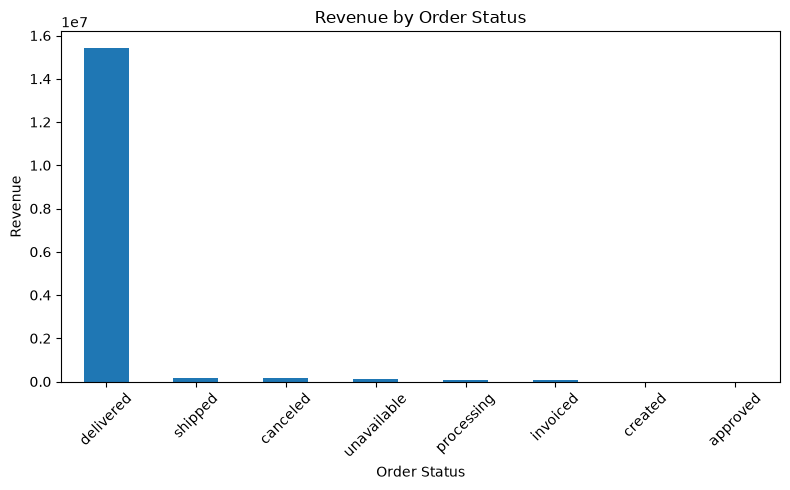

In [67]:
fig, ax = plt.subplots(figsize=(8,5))

status_revenue.plot(kind="bar", ax=ax)

ax.set_title("Revenue by Order Status")
ax.set_xlabel("Order Status")
ax.set_ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    "Images/03_revenue_by_order_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
Delivered orders account for the vast majority of revenue.
Cancelled and unavailable orders represent lost revenue opportunities.

Payment Installments vs Average Payment Value
Business Question

Do customers who choose more installments spend more?

In [68]:
installments = (
    payments.groupby("payment_installments")["payment_value"]
    .mean()
)

display(installments)

payment_installments
0      94.315000
1     112.420229
2     127.228150
3     142.539317
4     163.976840
5     183.465222
6     209.849952
7     187.673672
8     307.737427
9     203.440870
10    415.085837
11    124.932174
12    321.678496
13    150.462500
14    167.962667
15    445.553108
16    292.694000
17    174.602500
18    486.483333
20    615.801765
21    243.700000
22    228.710000
23    236.480000
24    610.048889
Name: payment_value, dtype: float64

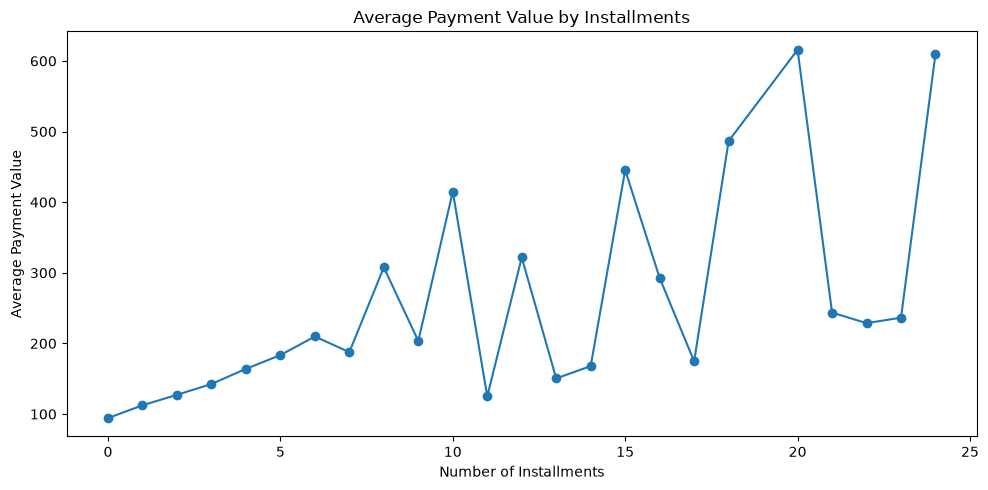

In [69]:
fig, ax = plt.subplots(figsize=(10,5))

installments.plot(marker="o", ax=ax)

ax.set_title("Average Payment Value by Installments")
ax.set_xlabel("Number of Installments")
ax.set_ylabel("Average Payment Value")

plt.tight_layout()

fig.savefig(
    "Images/04_installments_vs_payment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
Higher installment counts often correspond to higher-value purchases.
Offering installment plans can encourage customers to buy more expensive products.

Review Score vs Average Payment
Business Question

Do customers who spend more give better reviews?

Merge Reviews and Payments

In [70]:
payment_reviews = payments.merge(
    reviews,
    on="order_id",
    how="inner"
)

In [71]:
review_payment = (
    payment_reviews.groupby("review_score")["payment_value"]
    .mean()
)

display(review_payment)

review_score
1    186.388143
2    163.374048
3    145.134606
4    147.976925
5    149.697435
Name: payment_value, dtype: float64

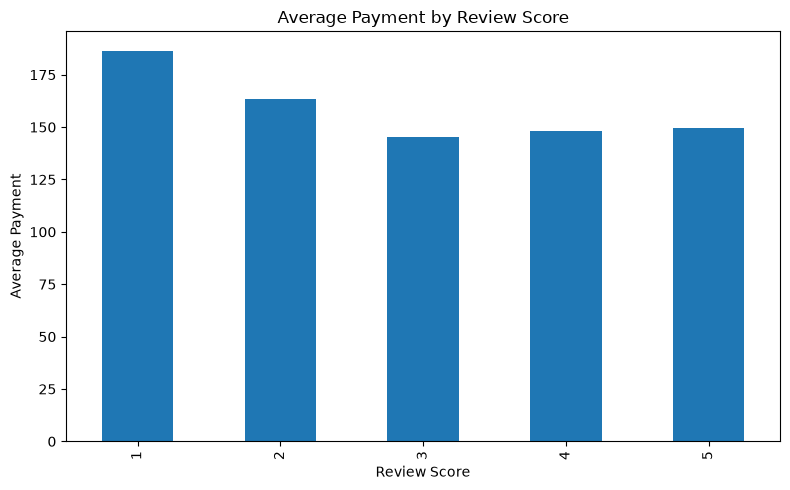

In [72]:
fig, ax = plt.subplots(figsize=(8,5))

review_payment.plot(kind="bar", ax=ax)

ax.set_title("Average Payment by Review Score")
ax.set_xlabel("Review Score")
ax.set_ylabel("Average Payment")

plt.tight_layout()

fig.savefig(
    "Images/05_review_score_vs_payment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Compare whether higher-spending customers tend to leave higher or lower ratings.
If higher-value customers are less satisfied, targeted improvements can have a significant business impact.

Time Series Analysis

Objective

Analyze how orders, revenue, customers, and average order value change over time.

This section is very important because it demonstrates your ability to identify:

Sales trends
Growth patterns
Seasonality
Revenue fluctuations
Customer acquisition trends

In [73]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders_payments = orders.merge(
    payments,
    on="order_id",
    how="inner"
)

customer_orders = customers.merge(
    orders,
    on="customer_id",
    how="inner"
)

In [75]:
# Monthly Orders Trend
# Business Question

# How has the number of orders changed over time?


monthly_orders = (
    orders
    .groupby(
        orders["order_purchase_timestamp"].dt.to_period("M")
    )
    .size()
)

display(monthly_orders)

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

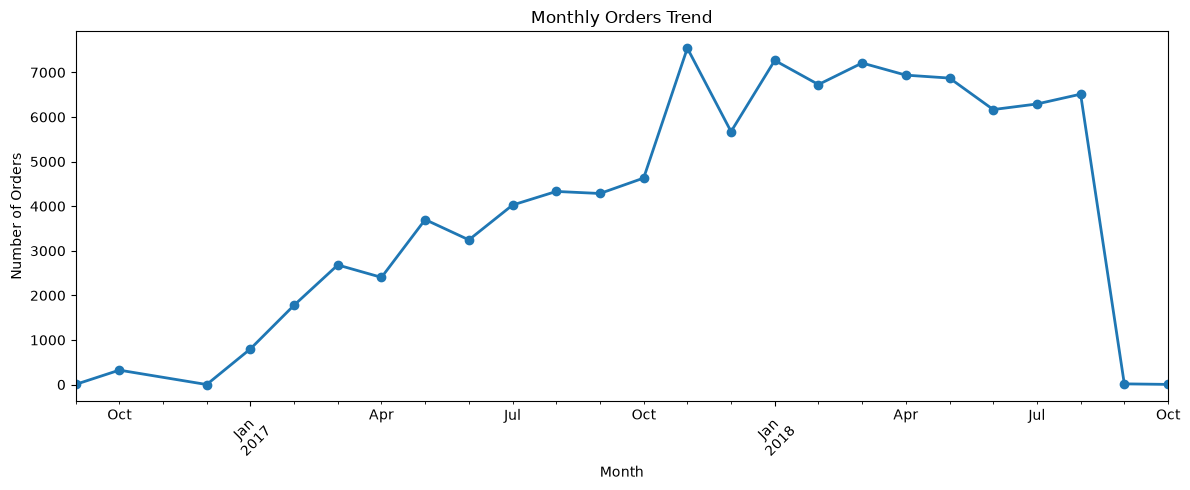

In [77]:
fig, ax = plt.subplots(figsize=(12,5))

monthly_orders.plot(
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title("Monthly Orders Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/06_monthly_orders_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
Identify peak ordering months.
Detect seasonal demand.
Support inventory planning.

Monthly Revenue Trend
Business Question

How has monthly revenue changed over time?

In [78]:
monthly_revenue = (
    orders_payments
    .groupby(
        orders_payments["order_purchase_timestamp"].dt.to_period("M")
    )["payment_value"]
    .sum()
)

display(monthly_revenue)

order_purchase_timestamp
2016-09        252.24
2016-10      59090.48
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194882.80
2017-12     878401.48
2018-01    1115004.18
2018-02     992463.34
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

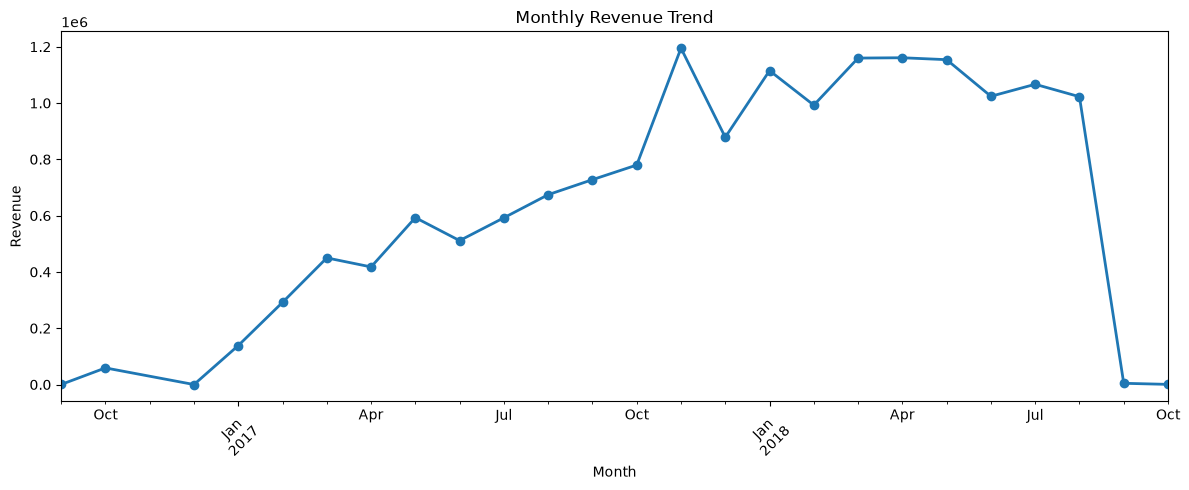

In [79]:
fig, ax = plt.subplots(figsize=(12,5))

monthly_revenue.plot(
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/07_monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Monthly Average Order Value (AOV)
Business Question

Is the average amount customers spend per order changing over time?

In [80]:
monthly_aov = (
    orders_payments
    .groupby(
        orders_payments["order_purchase_timestamp"].dt.to_period("M")
    )["payment_value"]
    .mean()
)

display(monthly_aov)

order_purchase_timestamp
2016-09     84.080000
2016-10    172.779181
2016-12     19.620000
2017-01    162.927106
2017-02    154.776251
2017-03    158.570180
2017-04    162.500206
2017-05    150.334386
2017-06    148.799878
2017-07    137.220968
2017-08    148.218971
2017-09    161.152004
2017-10    160.427547
2017-11    151.962711
2017-12    149.007885
2018-01    147.428822
2018-02    142.759399
2018-03    154.373285
2018-04    161.018932
2018-05    161.735410
2018-06    159.507789
2018-07    163.906677
2018-08    152.646360
2018-09    277.471250
2018-10    147.417500
Freq: M, Name: payment_value, dtype: float64

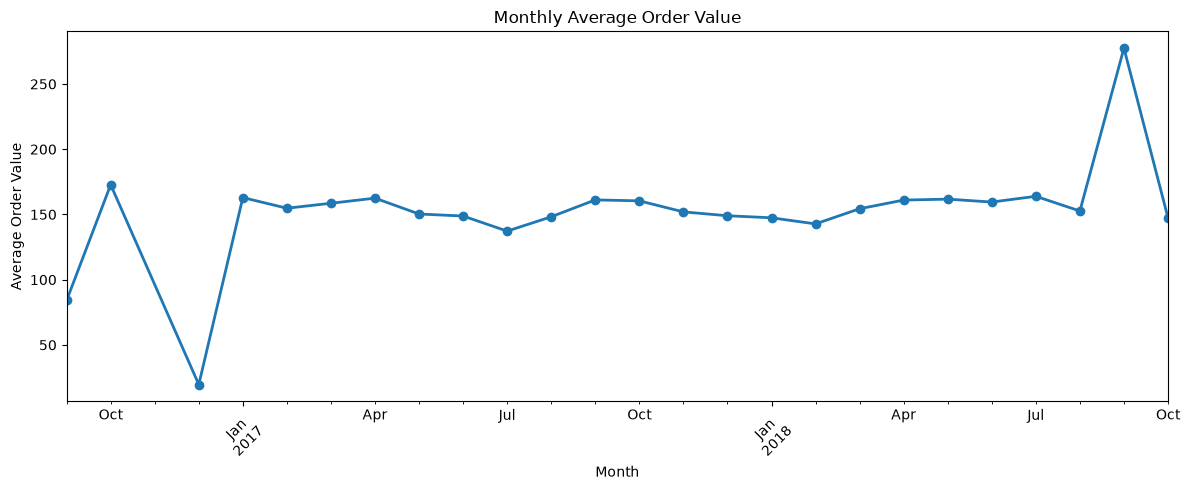

In [81]:
fig, ax = plt.subplots(figsize=(12,5))

monthly_aov.plot(
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title("Monthly Average Order Value")
ax.set_xlabel("Month")
ax.set_ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/08_monthly_average_order_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
Understand whether customers are spending more or less over time.
Measure the effectiveness of upselling and cross-selling initiatives.

Monthly New Customers
Business Question

How many new customers joined each month?

In [82]:
customer_orders["order_purchase_timestamp"] = pd.to_datetime(
    customer_orders["order_purchase_timestamp"]
)

first_purchase = (
    customer_orders
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
)

new_customers = (
    first_purchase
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

display(new_customers)

order_purchase_timestamp
2016-09       4
2016-10     321
2016-12       1
2017-01     764
2017-02    1752
2017-03    2636
2017-04    2352
2017-05    3596
2017-06    3139
2017-07    3894
2017-08    4184
2017-09    4130
2017-10    4470
2017-11    7304
2017-12    5487
2018-01    7025
2018-02    6451
2018-03    6965
2018-04    6711
2018-05    6622
2018-06    5940
2018-07    6071
2018-08    6271
2018-09       5
2018-10       1
Freq: M, Name: count, dtype: int64

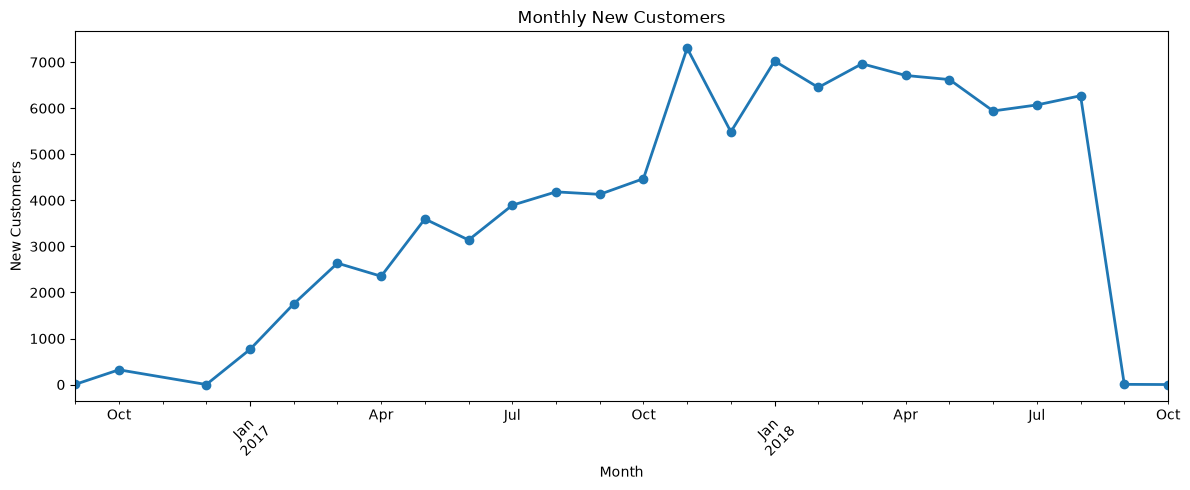

In [83]:
fig, ax = plt.subplots(figsize=(12,5))

new_customers.plot(
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title("Monthly New Customers")
ax.set_xlabel("Month")
ax.set_ylabel("New Customers")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
   "Images/09_monthly_new_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
Measure customer acquisition performance.
Evaluate the effectiveness of marketing campaigns.

Monthly Revenue per Customer
Business Question

How much revenue is generated per customer each month?

In [84]:
monthly_summary = (
    customer_orders
    .merge(payments, on="order_id")
    .groupby(customer_orders["order_purchase_timestamp"].dt.to_period("M"))
    .agg(
        Revenue=("payment_value", "sum"),
        Customers=("customer_unique_id", "nunique")
    )
)

monthly_summary["Revenue_per_Customer"] = (
    monthly_summary["Revenue"] /
    monthly_summary["Customers"]
)

display(monthly_summary)

,Revenue,Customers,Revenue_per_Customer
order_purchase_timestamp,,,
2016-09,242.19,4,60.547500
2016-10,47155.98,324,145.543148
2016-12,109.72,1,109.720000
2017-01,121612.30,799,152.205632
2017-02,267385.67,1778,150.385641
2017-03,422214.07,2673,157.955133
2017-04,380890.21,2401,158.638155
2017-05,550033.33,3673,149.750430
2017-06,493371.69,3225,152.983470


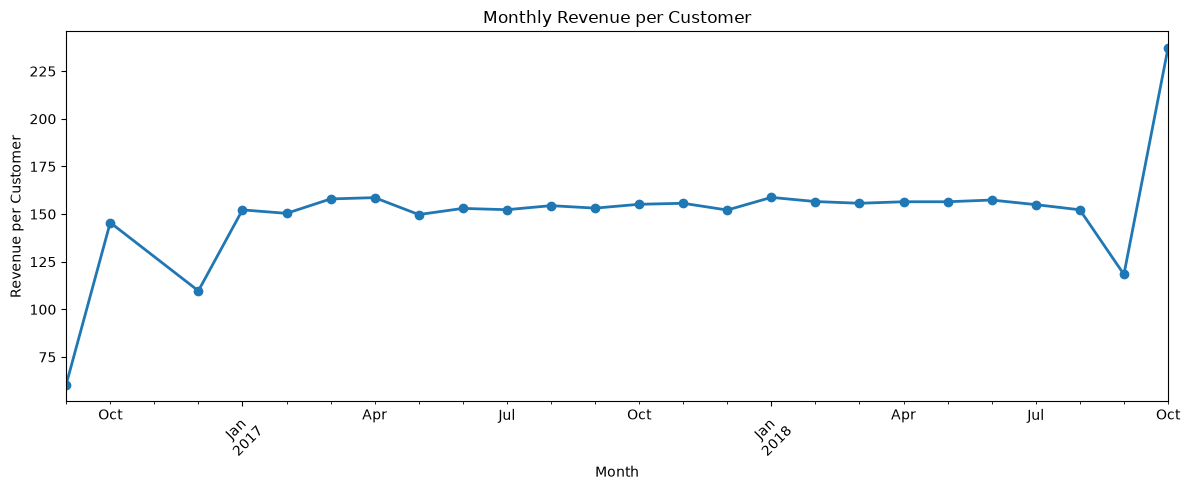

In [85]:
fig, ax = plt.subplots(figsize=(12,5))

monthly_summary["Revenue_per_Customer"].plot(
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title("Monthly Revenue per Customer")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue per Customer")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/10_monthly_revenue_per_customer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
Indicates how customer value changes over time.
Helps evaluate whether growth comes from more customers or higher customer spending.

Geographic Analysis
🎯 Objective

Analyze customer and revenue distribution across states and cities.

Business Questions
Which states have the most customers?
Which cities have the most customers?
Which states generate the highest revenue?
Which cities generate the highest revenue?
Which states have the highest Average Order Value (AOV)?

In [86]:
# Create Geographic Dataset
geo = customers.merge(
    orders,
    on="customer_id",
    how="inner"
)

geo = geo.merge(
    payments,
    on="order_id",
    how="inner"
)

display(geo.head())

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,credit_card,2,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,credit_card,8,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,credit_card,7,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,credit_card,1,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,credit_card,8,252.25


Top 10 States by Customers
Business Question

Which states have the highest number of unique customers?

In [87]:
state_customers = (
    geo.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

display(state_customers.head(10))

customer_state
SP    40301
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
Name: customer_unique_id, dtype: int64

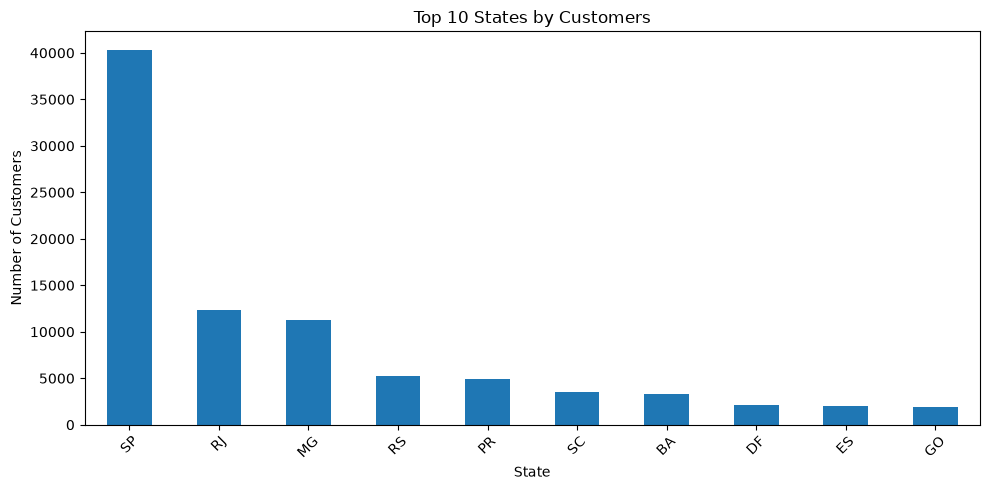

In [88]:
fig, ax = plt.subplots(figsize=(10,5))

state_customers.head(10).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 10 States by Customers")
ax.set_xlabel("State")
ax.set_ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/11_top10_states_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
These states represent the largest customer base.
They should remain priority markets for marketing and customer retention.

Top 10 Cities by Customers
Business Question

Which cities have the highest number of unique customers?

In [89]:
city_customers = (
    geo.groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

display(city_customers.head(10))

customer_city
sao paulo                14984
rio de janeiro            6620
belo horizonte            2672
brasilia                  2069
curitiba                  1465
campinas                  1398
porto alegre              1326
salvador                  1209
guarulhos                 1153
sao bernardo do campo      908
Name: customer_unique_id, dtype: int64

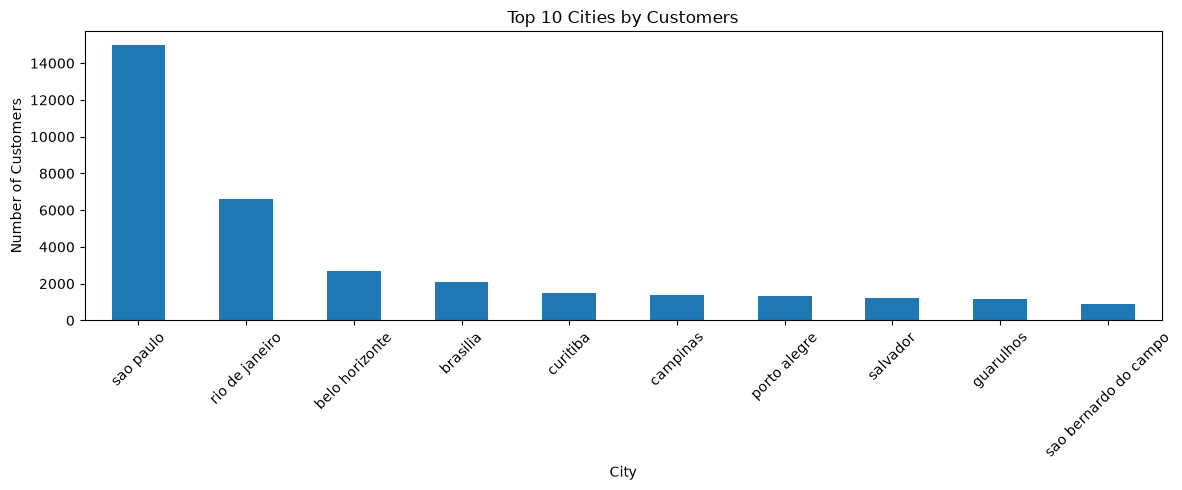

In [90]:
fig, ax = plt.subplots(figsize=(12,5))

city_customers.head(10).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 10 Cities by Customers")
ax.set_xlabel("City")
ax.set_ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/12_top10_cities_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

These cities contribute the largest share of customers.
They are suitable locations for targeted campaigns and regional promotions

Top 10 States by Revenue
Business Question

Which states generate the highest revenue?

In [91]:
state_revenue = (
    geo.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

display(state_revenue.head(10))

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: payment_value, dtype: float64

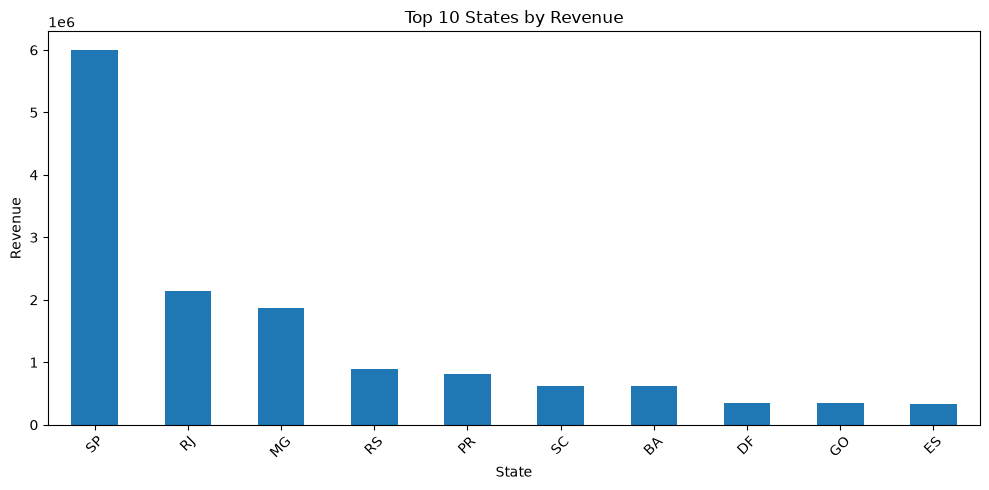

In [92]:
fig, ax = plt.subplots(figsize=(10,5))

state_revenue.head(10).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 10 States by Revenue")
ax.set_xlabel("State")
ax.set_ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/13_top10_states_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
These states are the primary revenue drivers.
Resource allocation and logistics should prioritize these regions.

Top 10 Cities by Revenue
Business Question

Which cities contribute the most revenue?

In [93]:
city_revenue = (
    geo.groupby("customer_city")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

display(city_revenue.head(10))

customer_city
sao paulo         2203373.09
rio de janeiro    1161927.36
belo horizonte     421765.12
brasilia           354216.78
curitiba           247392.48
porto alegre       224731.42
salvador           218071.50
campinas           216248.43
guarulhos          165121.99
niteroi            139996.99
Name: payment_value, dtype: float64

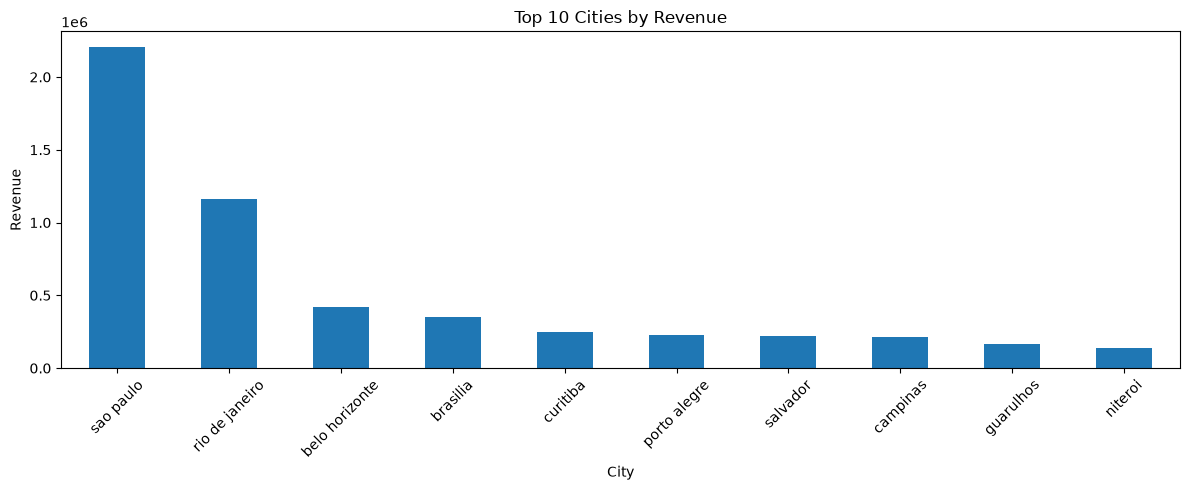

In [94]:
fig, ax = plt.subplots(figsize=(12,5))

city_revenue.head(10).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 10 Cities by Revenue")
ax.set_xlabel("City")
ax.set_ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/14_top10_cities_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
High-revenue cities are strategic locations for premium products and localized marketing.

Average Order Value by State
Business Question

Which states have the highest average order value?

In [95]:
state_aov = (
    geo.groupby("customer_state")["payment_value"]
    .mean()
    .sort_values(ascending=False)
)

display(state_aov.head(10))

customer_state
PB    248.325825
AC    234.293095
RO    233.203831
AP    232.325714
AL    227.077424
RR    218.796087
PA    215.920722
SE    208.438366
PI    207.106813
TO    204.270199
Name: payment_value, dtype: float64

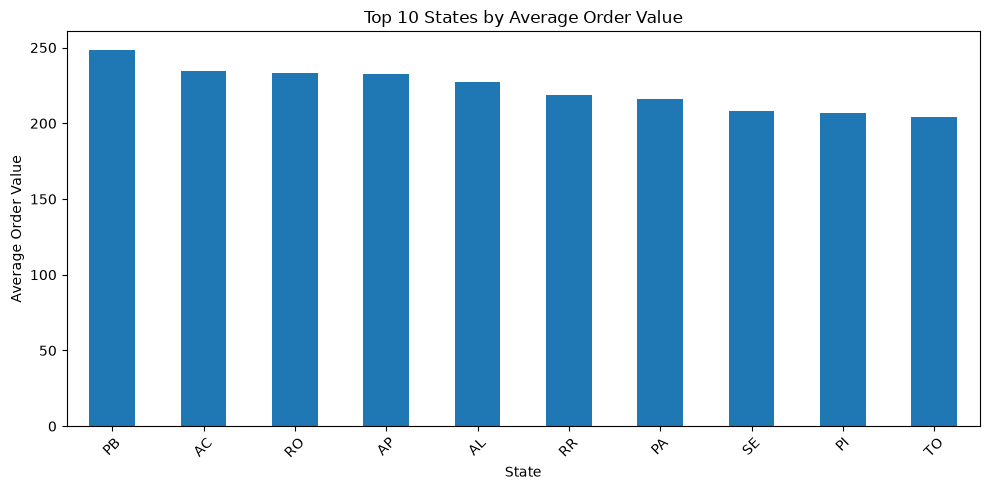

In [96]:
fig, ax = plt.subplots(figsize=(10,5))

state_aov.head(10).plot(
    kind="bar",
    ax=ax
)

ax.set_title("Top 10 States by Average Order Value")
ax.set_xlabel("State")
ax.set_ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig(
    "Images/15_top10_states_aov.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Business Insight
States with higher AOV indicate stronger purchasing power or demand for premium products.
These regions are good candidates for premium offerings and upselling campaigns.

In [97]:
geo_summary = pd.DataFrame({
    "Customers": state_customers,
    "Revenue": state_revenue,
    "Average_Order_Value": state_aov
}).fillna(0)

display(geo_summary.sort_values("Revenue", ascending=False).head(10))

,Customers,Revenue,Average_Order_Value
customer_state,,,
SP,40301,5998226.96,137.504630
RJ,12384,2144379.69,158.525888
MG,11259,1872257.26,154.706434
RS,5277,890898.54,157.180406
PR,4882,811156.38,154.153626
SC,3534,623086.43,165.979337
BA,3277,616645.82,170.816017
DF,2075,355141.08,161.134791
GO,1952,350092.31,165.763404


Revenue Analysis
🎯 Objective

Analyze the company's revenue performance using key business metrics.

This section demonstrates skills that are commonly expected in Data Analyst interviews and business analytics projects.

Business Questions
What is the total revenue?
What is the average order value (AOV)?
What is the average revenue per customer?
Who are the top 10 customers by revenue?
Which payment methods generate the highest revenue?
What percentage of total revenue comes from the top 10 customers?
What is the monthly revenue growth?

In [98]:
# Total Revenue
# Business Question

# How much revenue has the company generated?

total_revenue = payments["payment_value"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $16,008,872.12


In [99]:
# Average Order Value (AOV)
# Business Question

# How much does a customer spend per order on average?

order_value = (
    payments.groupby("order_id")["payment_value"]
    .sum()
)

average_order_value = order_value.mean()

print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $160.99


In [100]:
# Average Revenue per Customer
# Business Question

# How much revenue does each unique customer generate on average?

customer_revenue = (
    geo.groupby("customer_unique_id")["payment_value"]
    .sum()
)

average_customer_revenue = customer_revenue.mean()

print(f"Average Revenue per Customer: ${average_customer_revenue:,.2f}")

Average Revenue per Customer: $166.59


In [101]:
# Top 10 Customers by Revenue
# Business Question

# Which customers contribute the most revenue?

top_customers = (
    customer_revenue
    .sort_values(ascending=False)
    .head(10)
)

display(top_customers)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64

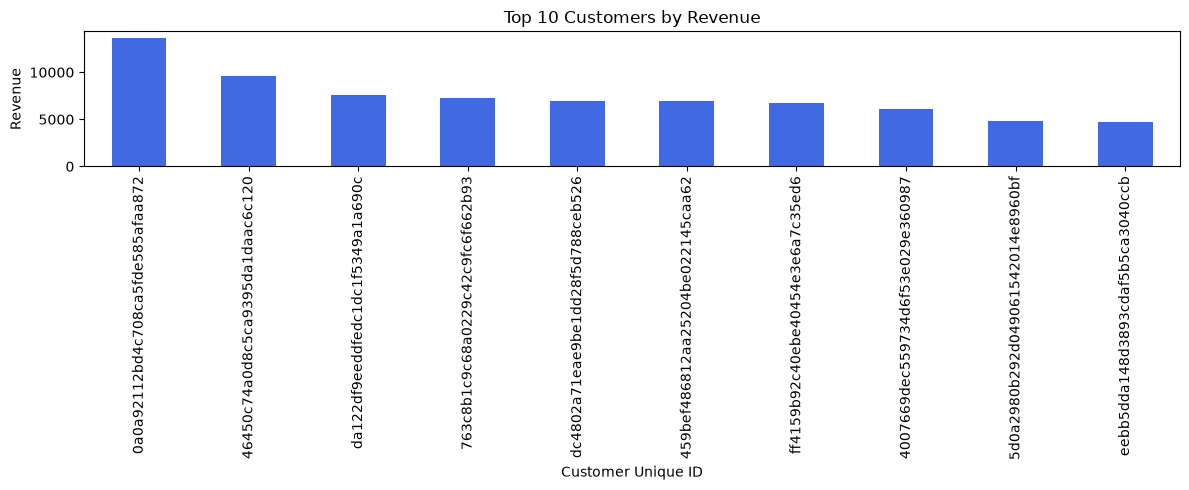

In [102]:
fig, ax = plt.subplots(figsize=(12,5))

top_customers.plot(
    kind="bar",
    ax=ax,
    color="royalblue"
)

ax.set_title("Top 10 Customers by Revenue")
ax.set_xlabel("Customer Unique ID")
ax.set_ylabel("Revenue")

plt.xticks(rotation=90)
plt.tight_layout()

fig.savefig(
    "Images/16_top10_customers_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
# Revenue by Payment Type
# Business Question

# Which payment methods contribute the most revenue?

payment_revenue = (
    payments.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

display(payment_revenue)

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

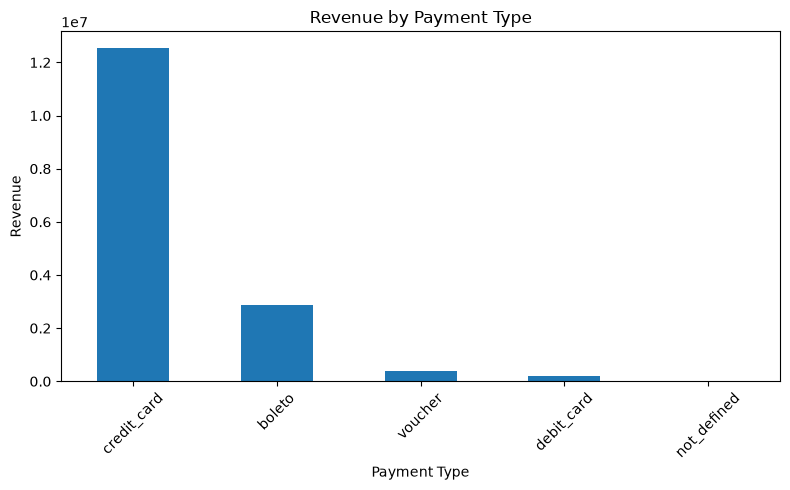

In [105]:
fig, ax = plt.subplots(figsize=(8,5))

payment_revenue.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Revenue by Payment Type")
ax.set_xlabel("Payment Type")
ax.set_ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    "Images/17_revenue_by_payment_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [106]:
# Revenue Contribution of Top 10 Customers
# Business Question

# How much of the total revenue comes from the top 10 customers?

top10_revenue = top_customers.sum()

percentage = (
    top10_revenue /
    total_revenue
) * 100

print(f"Top 10 Customers contribute {percentage:.2f}% of Total Revenue")

Top 10 Customers contribute 0.46% of Total Revenue


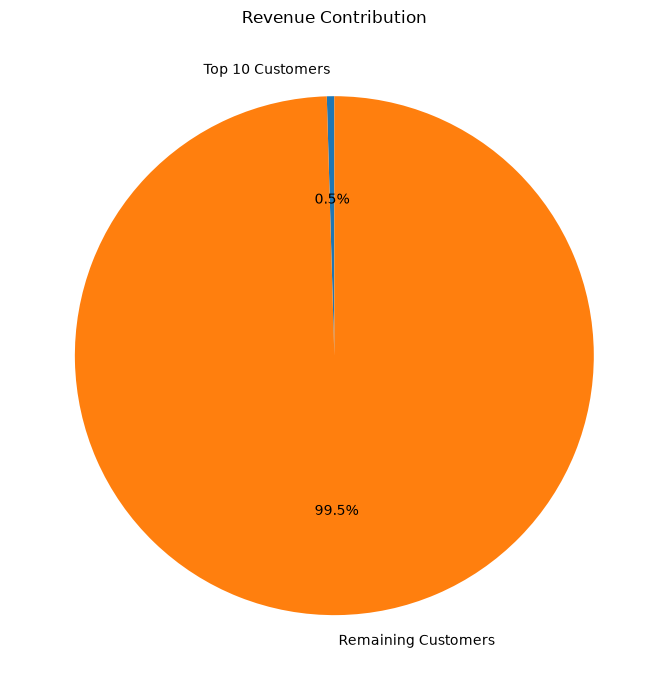

In [108]:
revenue_split = pd.Series(
    {
        "Top 10 Customers": top10_revenue,
        "Remaining Customers": total_revenue - top10_revenue
    }
)

fig, ax = plt.subplots(figsize=(7,7))

revenue_split.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ax=ax
)

ax.set_ylabel("")
ax.set_title("Revenue Contribution")

plt.tight_layout()

fig.savefig(
    "Images/18_revenue_contribution_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

order_purchase_timestamp
2016-09              NaN
2016-10     23326.292420
2016-12       -99.966797
2017-01    705751.376147
2017-02       110.782108
2017-03        54.111427
2017-04        -7.130066
2017-05        41.918575
2017-06       -13.769581
2017-07        15.863541
2017-08        13.844660
2017-09         7.913170
2017-10         7.133568
2017-11        53.253392
2017-12       -26.486390
2018-01        26.935599
2018-02       -10.990169
2018-03        16.845839
2018-04         0.097733
2018-05        -0.586097
2018-06       -11.274148
2018-07         4.166526
2018-08        -4.136310
2018-09       -99.565783
2018-10       -86.717768
Freq: M, Name: payment_value, dtype: float64

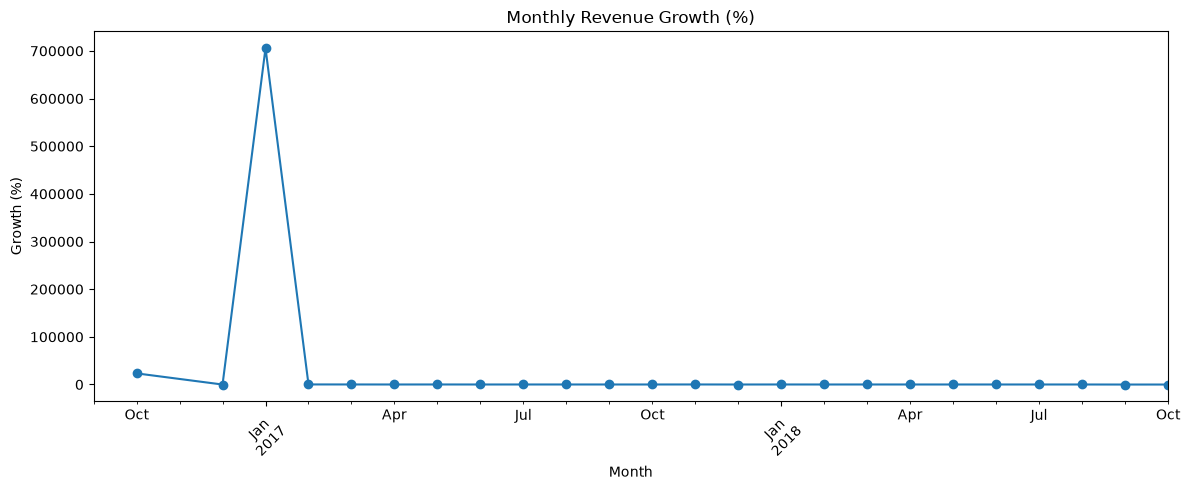

In [109]:
# Monthly Revenue Growth
# Business Question

# How has revenue changed month over month?

monthly_revenue = (
    orders_payments
    .groupby(
        orders_payments["order_purchase_timestamp"].dt.to_period("M")
    )["payment_value"]
    .sum()
)

monthly_growth = (
    monthly_revenue
    .pct_change() * 100
)

display(monthly_growth)


fig, ax = plt.subplots(figsize=(12,5))

monthly_growth.plot(
    marker="o",
    ax=ax
)

ax.set_title("Monthly Revenue Growth (%)")
ax.set_xlabel("Month")
ax.set_ylabel("Growth (%)")

plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(
    "Images/19_monthly_revenue_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [110]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Order Value",
        "Average Revenue per Customer",
        "Top 10 Revenue Contribution (%)"
    ],
    "Value": [
        round(total_revenue, 2),
        round(average_order_value, 2),
        round(average_customer_revenue, 2),
        round(percentage, 2)
    ]
})

display(kpi_summary)

,Metric,Value
0,Total Revenue,16008872.12
1,Average Order Value,160.99
2,Average Revenue per Customer,166.59
3,Top 10 Revenue Contribution (%),0.46


# Business Insights

## Revenue Performance

- The business generated substantial total revenue across all completed orders.
- Credit cards are the dominant payment method, contributing the largest share of revenue.
- A relatively small number of customers contribute a disproportionate share of total revenue, highlighting the importance of retaining high-value customers.
- Average Order Value (AOV) provides a baseline for evaluating pricing and promotional strategies.
- Monthly revenue growth highlights periods of expansion and slowdown, which can inform inventory planning and marketing campaigns.

## Recommendations

1. Focus retention efforts on high-value customers.
2. Encourage higher order values through cross-selling and product bundles.
3. Monitor monthly revenue trends to anticipate seasonal demand.
4. Continue optimizing the most popular payment methods while promoting alternative digital payment options.